<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/decision_tree_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [ ]:
adv_df = pd.read_csv("Advertising_Data.csv")
adv_df

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
0,281.42,538.80,123.94,349.30,242.77,910.10,7164.0
1,702.97,296.53,558.13,180.55,781.06,132.43,5055.0
2,313.14,295.94,642.96,505.71,438.91,464.23,6154.0
3,898.52,61.27,548.73,240.93,278.96,432.27,5480.0
4,766.52,550.72,651.91,666.33,396.33,841.93,9669.0
...,...,...,...,...,...,...,...
295,770.05,501.36,694.60,172.26,572.26,410.56,6851.0
296,512.38,250.83,373.78,366.95,987.14,509.03,6477.0
297,998.10,858.75,781.06,60.61,174.63,213.53,6949.0
298,322.35,681.22,640.29,343.65,534.22,648.71,7737.0


In [ ]:
x = adv_df.drop(columns=['Product_Sold'])
y = adv_df['Product_Sold']

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state=7)

In [ ]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(xtrain, ytrain)

DecisionTreeRegressor(max_depth=5)

In [ ]:
ytrain_preds = model.predict(xtrain)
r2_score(ytrain, ytrain_preds)

0.8896044321813711

In [ ]:
ytest_preds = model.predict(xtest)
r2_score(ytest, ytest_preds)

0.5281237865197348

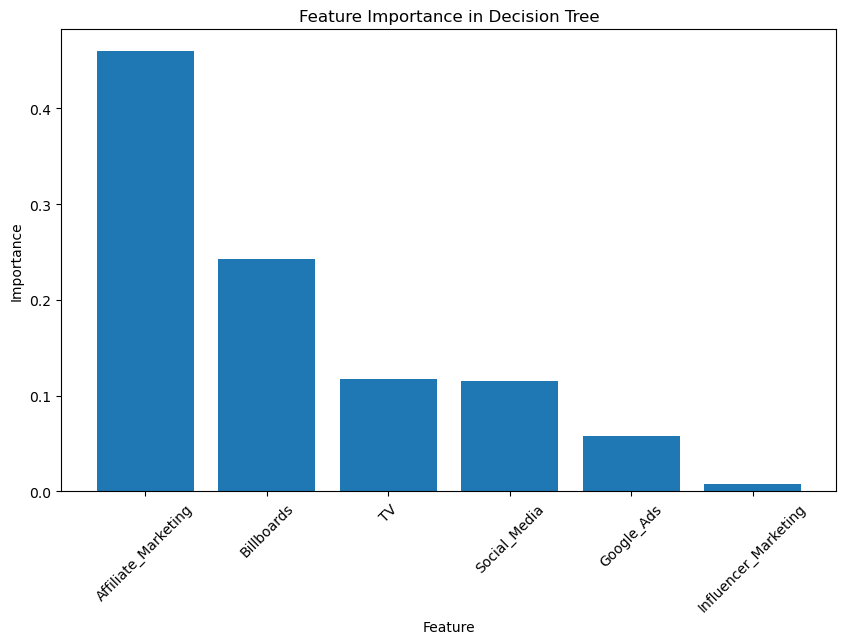

In [ ]:
feature_names = xtrain.columns
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_feature_names = [feature_names[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Decision Tree")
plt.bar(range(xtrain.shape[1]), importances[indices], align='center')
plt.xticks(range(xtrain.shape[1]), sorted_feature_names, rotation=45)
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()